# Optimization of Industrial Uptime: A Comparative Analysis of Machine Failure Prediction using GMMs and Support Vector Machines

**Dataset:** Predictive Maintenance Dataset (AI4I 2020)  
**Module:** Data Analytics ECS784U/P  
**Date:** 12/03/2026


### 1) Exporatory Data Analysis Using Pandas

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, classification_report, precision_score, recall_score
from sklearn.svm import SVC
from sklearn import svm


In [6]:
df = pd.read_csv('ai4i2020.csv')
print(df.columns)
print(df.dtypes)
print(df.shape)

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object
(10000, 14)


In [32]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Rotational_Speed_Log,Torque_Log,Tool_Wear_Log,Temp_Diff,Power,Strain
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190,7.332673,3.653656,4.354921,10.000630,6279.744953,4314.664550
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355,0.107515,0.275829,1.034984,1.001094,1067.418295,2826.567692
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.063048,1.335001,0.000000,7.600000,1148.440610,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.260523,3.502550,3.970292,9.300000,5561.184484,1963.650000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.315218,3.691376,4.682131,9.800000,6271.027344,4012.950000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,7.385231,3.845883,5.087596,11.000000,7003.002724,6279.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,7.967627,4.338597,5.533389,12.100000,10469.923005,16497.000000


In [7]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [8]:
df.describe

<bound method NDFrame.describe of         UDI Product ID Type  Air temperature [K]  Process temperature [K]  \
0         1     M14860    M                298.1                    308.6   
1         2     L47181    L                298.2                    308.7   
2         3     L47182    L                298.1                    308.5   
3         4     L47183    L                298.2                    308.6   
4         5     L47184    L                298.2                    308.7   
...     ...        ...  ...                  ...                      ...   
9995   9996     M24855    M                298.8                    308.4   
9996   9997     H39410    H                298.9                    308.4   
9997   9998     M24857    M                299.0                    308.6   
9998   9999     H39412    H                299.0                    308.7   
9999  10000     M24859    M                299.0                    308.7   

      Rotational speed [rpm]  Torque [Nm]

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [12]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [13]:
print('Values and counts for Machine failure are:')
print(df['Machine failure'].value_counts())
print()
print('Normalised counts for Machine failure are:')
print(df['Machine failure'].value_counts(normalize=True))

Values and counts for Machine failure are:
Machine failure
0    9661
1     339
Name: count, dtype: int64

Normalised counts for Machine failure are:
Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64


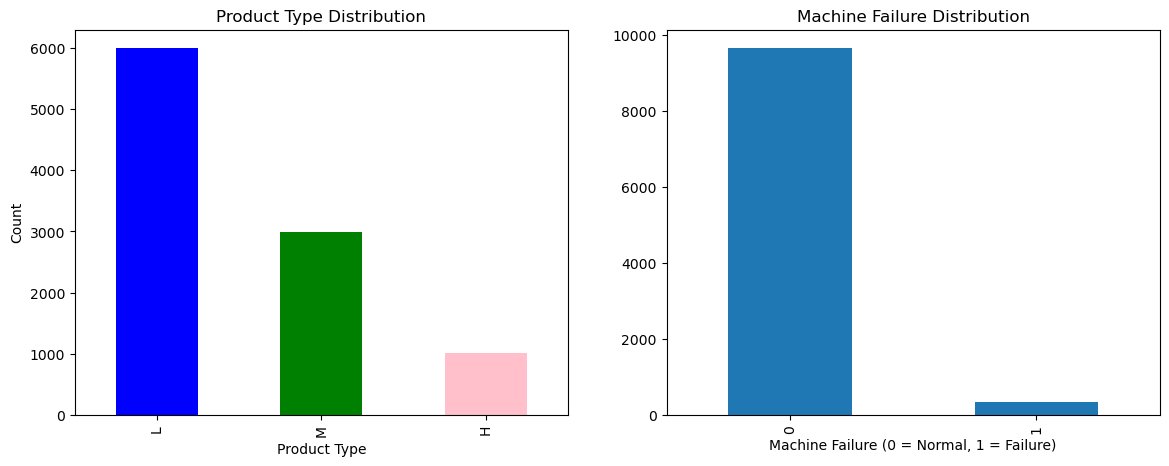

In [15]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (14, 5))
df['Type'].value_counts().plot(ax = axes[0], kind = 'bar',
                               title = 'Product Type Distribution',
                               color = ['blue', 'green', 'pink'],
                               ylabel = 'Count', xlabel = 'Product Type')
df['Machine failure'].value_counts().plot(ax = axes[1], kind = 'bar',
                                          title = 'Machine Failure Distribution',
                                          xlabel = 'Machine Failure (0 = Normal, 1 = Failure)')
plt.show()

counts for type vs. machine failure: 
Machine failure     0    1
Type                      
H                 982   21
L                5765  235
M                2914   83

 normalised counts for type vs. machine failure: 
Machine failure         0         1
Type                               
H                0.979063  0.020937
L                0.960833  0.039167
M                0.972306  0.027694


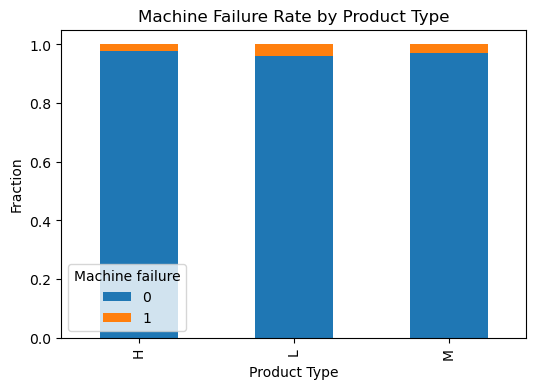

In [ ]:
#bivariate analysis: product type vs. machine failure
type_status = pd.crosstab(df['Type'], df['Machine failure'])
print("counts for type vs. machine failure: ")
print(type_status)

type_status = type_status.div(type_status.sum(1).astype(float), axis = 0)
print("\n normalised counts for type vs. machine failure: ")
print(type_status)

type_status.plot(kind = 'bar', stacked = True, figsize = (6, 4),
                 xlabel = 'Product Type', ylabel = 'Fraction', 
                 title = 'Machine Failure Rate by Product Type')
plt.show()

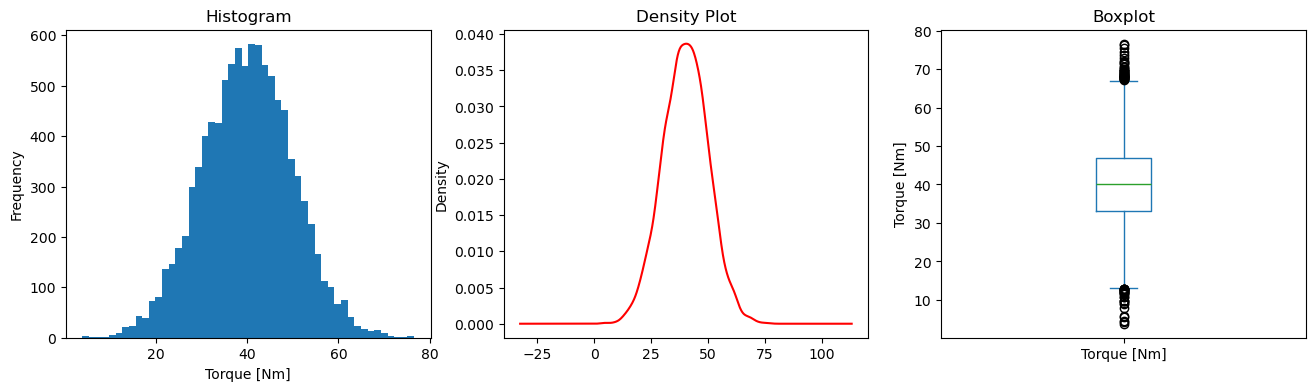

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 4))
df['Torque [Nm]'].plot(kind='hist', bins=50, ax=axes[0],
                       xlabel='Torque [Nm]', title='Histogram')
df['Torque [Nm]'].plot(kind='density', color='r', ax=axes[1], title='Density Plot')
df['Torque [Nm]'].plot(kind='box', ax=axes[2], ylabel='Torque [Nm]',
                       xlabel='', title='Boxplot')
plt.show()

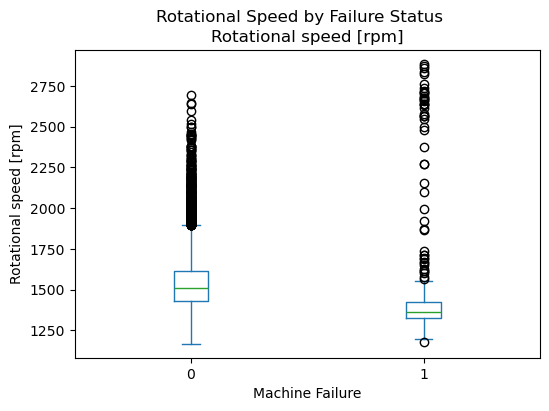

In [26]:
#bivariate analysis: rotational speed vs machine failure
df.plot(column = 'Rotational speed [rpm]', by = 'Machine failure', kind = 'box', 
        subplots=False, xlabel = 'Machine Failure', ylabel = 'Rotational speed [rpm]', 
        title = 'Rotational Speed by Failure Status', figsize= (6, 4))
plt.xlabel('Machine Failure')
plt.show()

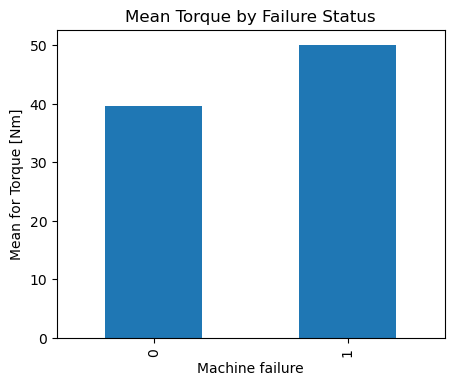

In [27]:
#mean of each continuous variable grouped by failure status
df.groupby('Machine failure')['Torque [Nm]'].mean().plot(kind = 'bar',
                                                         ylabel = 'Mean for Torque [Nm]',
                                                         figsize = (5, 4),
                                                         title = 'Mean Torque by Failure Status')
plt.show()

### 2) Data Preprocessing

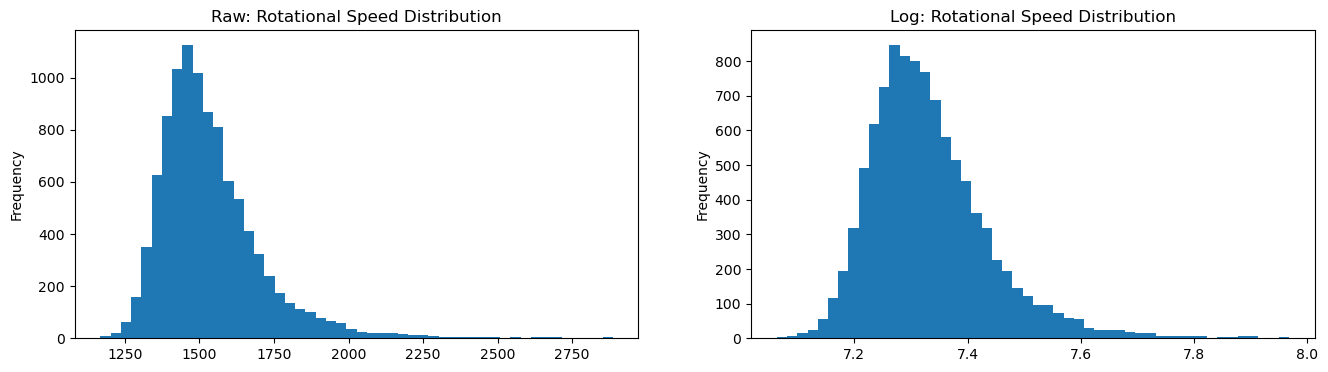

In [29]:
df['Rotational_Speed_Log'] = np.log(df['Rotational speed [rpm]'])
df['Torque_Log'] = np.log(df['Torque [Nm]'])
df['Tool_Wear_Log'] = np.log(df['Tool wear [min]'].replace(0, 1))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))
df['Rotational speed [rpm]'].plot(kind='hist', bins=50, ax=axes[0],
                                  title='Raw: Rotational Speed Distribution')
df['Rotational_Speed_Log'].plot(kind='hist', bins=50, ax=axes[1],
                                title='Log: Rotational Speed Distribution')
plt.show()

### 3) Feature Engineering

In [31]:
df['Temp_Diff'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Power'] = df['Torque [Nm]']* (2* np.pi* df['Rotational speed [rpm]']/60)
df['Strain'] = df['Tool wear [min]'] * df['Torque [Nm]']
print(df.columns.tolist())
df[['Temp_Diff', 'Power', 'Strain']].describe()

['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'Rotational_Speed_Log', 'Torque_Log', 'Tool_Wear_Log', 'Temp_Diff', 'Power', 'Strain']


,Temp_Diff,Power,Strain
count,10000.000000,10000.000000,10000.000000
mean,10.000630,6279.744953,4314.664550
std,1.001094,1067.418295,2826.567692
min,7.600000,1148.440610,0.000000
25%,9.300000,5561.184484,1963.650000
50%,9.800000,6271.027344,4012.950000
75%,11.000000,7003.002724,6279.000000
max,12.100000,10469.923005,16497.000000


In [35]:
#categorical variables to integer
print('Type is originally a string variable:')
print(df['Type'].value_counts())

df['Type'] = df['Type'].astype('category').cat.codes
print('\nType has been converted to integer: ')
print(df['Type'].value_counts())

#drop columns to prevent data leakage
df = df.drop(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)
print('\n Data frame after encoding and dropping leakage columns:')
df.head()

Type is originally a string variable:
Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

Type has been converted to integer: 
Type
1    6000
2    2997
0    1003
Name: count, dtype: int64

 Data frame after encoding and dropping leakage columns:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Rotational_Speed_Log,Torque_Log,Tool_Wear_Log,Temp_Diff,Power,Strain
0,1,M14860,2,298.1,308.6,1551,42.8,0,0,7.346655,3.756538,0.000000,10.5,6951.590560,0.0
1,2,L47181,1,298.2,308.7,1408,46.3,3,0,7.249926,3.835142,1.098612,10.5,6826.722724,138.9
2,3,L47182,1,298.1,308.5,1498,49.4,5,0,7.311886,3.899950,1.609438,10.4,7749.387543,247.0
3,4,L47183,1,298.2,308.6,1433,39.5,7,0,7.267525,3.676301,1.945910,10.4,5927.504659,276.5
4,5,L47184,1,298.2,308.7,1408,40.0,9,0,7.249926,3.688879,2.197225,10.5,5897.816608,360.0


### Classification Using Support Vector Machine (SVM)

In [ ]:
#SVM


svc = svm.SVC(kernel = 'linear').fit(x,y)


### Clustering Using K-means and Gaussian Mixture Model (GMM)